Duplicated player-date valuations: 0
Players with a pre-season market value: 38979
Players with a target market value: 16707
Players actually excluded because they entered or left the top five after the summer window: 288
       player_id transfer_date  from_club_name     to_club_name  \
25986    1052291    2024-09-02   Saint-Étienne              QRM   
25865      52769    2024-09-02          Fulham       Olympiacos   
25876     211474    2024-09-02         SM Caen             Nice   
25880     256977    2024-09-02          Wolves        Al-Shabab   
25942     666234    2024-09-02         Leipzig         Al-Nassr   
...          ...           ...             ...              ...   
20146     719442    2025-02-17            Lens         Portland   
19929     943837    2025-02-28       Barcelona        Palmeiras   
19891     926301    2025-03-01  M'gladbach U19  Mönchengladbach   
19718    1200289    2025-03-15      Guidars FC   Stade Brestois   
19500     980632    2025-04-15      Torin

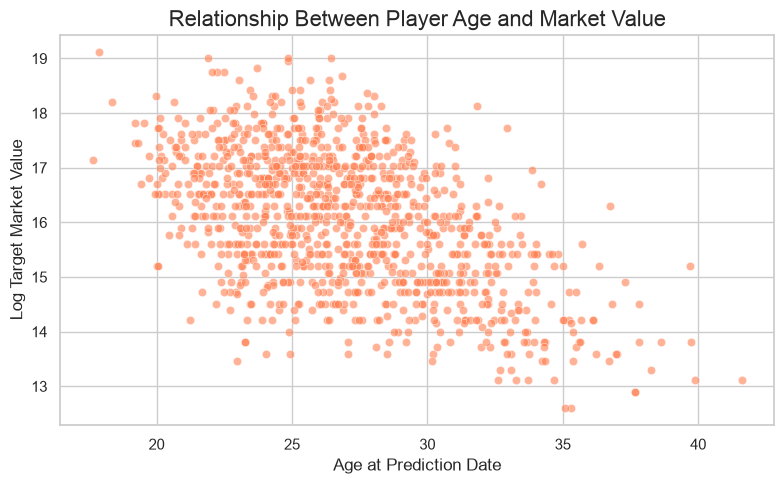

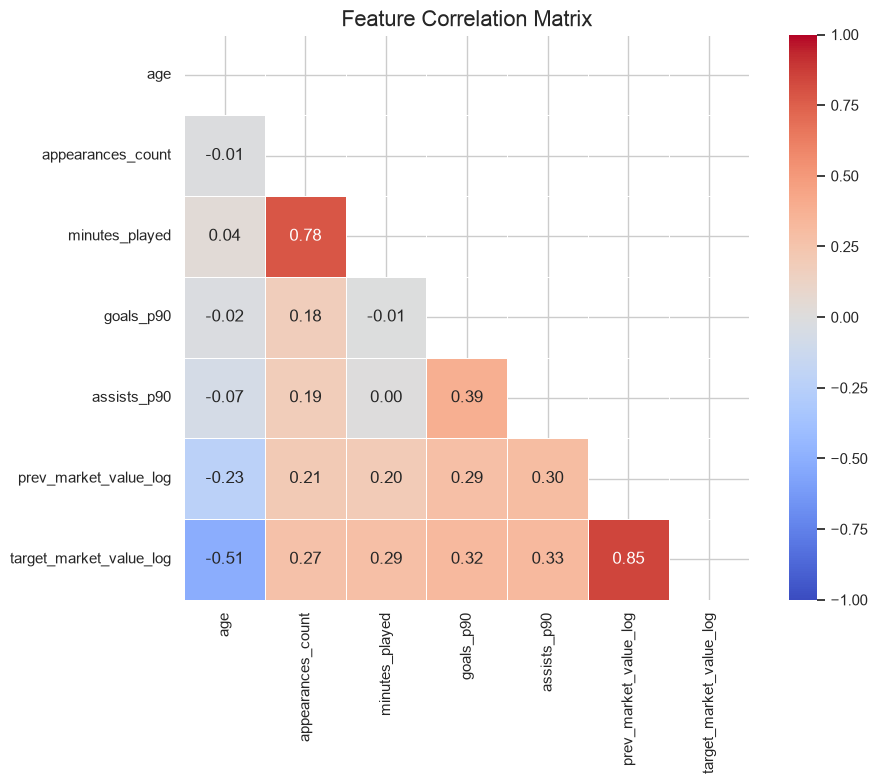

In [1]:
# =========================================================
# COMPLETE DATA PREPARATION, QUALITY CHECKS AND EDA
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ---------------------------------------------------------
# 1. LOAD THE DATA
# ---------------------------------------------------------

appearances = pd.read_csv('appearances.csv')
players = pd.read_csv('players.csv')
valuations = pd.read_csv('player_valuations.csv')
transfers = pd.read_csv('transfers.csv')


# ---------------------------------------------------------
# 2. DEFINE PROJECT SCOPE AND TEMPORAL CUTOFFS
# ---------------------------------------------------------

top_leagues = ['GB1', 'IT1', 'ES1', 'L1', 'FR1']

# First date included in the collection of seasonal statistics.
# Pre-season valuations must be strictly earlier than this date.
season_start_date = pd.Timestamp('2024-08-15')

# Players entering or leaving the top five after this date
# and before the prediction date are excluded.
summer_window_end = pd.Timestamp('2024-09-01')

# Final date included in the seasonal statistics.
# Players must have accumulated at least 900 minutes by this date.
# Target valuations must be strictly later than this date.
prediction_date = pd.Timestamp('2025-05-25')

# Final date included in the target-valuation window.
target_window_end = pd.Timestamp('2025-08-15')

assert (
    season_start_date
    < summer_window_end
    < prediction_date
    < target_window_end
)


# ---------------------------------------------------------
# 3. CLEAN VALUATION DATA
# ---------------------------------------------------------

valuations['date'] = pd.to_datetime(
    valuations['date'],
    errors='coerce'
)

valuations_clean = valuations.dropna(
    subset=[
        'player_id',
        'date',
        'market_value_in_eur'
    ]
).copy()

# Market values must be positive before applying log1p().
valuations_clean = valuations_clean[
    valuations_clean['market_value_in_eur'] > 0
].copy()

# Check for duplicated valuations for the same player
# on the same date.
duplicated_valuations = valuations_clean.duplicated(
    subset=['player_id', 'date']
).sum()

print(
    'Duplicated player-date valuations:',
    duplicated_valuations
)


# ---------------------------------------------------------
# 4. SELECT THE PRE-SEASON MARKET VALUE
# ---------------------------------------------------------

preseason_valuations = valuations_clean[
    valuations_clean['date'] < season_start_date
].copy()

# Select the latest valuation before the beginning
# of the season for each player.
latest_pre_indices = (
    preseason_valuations
    .groupby('player_id')['date']
    .idxmax()
)

latest_pre_val = (
    preseason_valuations
    .loc[
        latest_pre_indices,
        ['player_id', 'date', 'market_value_in_eur']
    ]
    .rename(
        columns={
            'date': 'prev_valuation_date',
            'market_value_in_eur':
                'prev_market_value_in_eur'
        }
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 5. SELECT THE TARGET MARKET VALUE
# ---------------------------------------------------------

target_window = valuations_clean[
    (valuations_clean['date'] > prediction_date)
    & (valuations_clean['date'] <= target_window_end)
].copy()

# Select the first valuation in the target window
# for each player.
earliest_target_indices = (
    target_window
    .groupby('player_id')['date']
    .idxmin()
)

target_values = (
    target_window
    .loc[
        earliest_target_indices,
        ['player_id', 'date', 'market_value_in_eur']
    ]
    .rename(
        columns={
            'date': 'target_valuation_date',
            'market_value_in_eur':
                'target_market_value_in_eur'
        }
    )
    .reset_index(drop=True)
)

print(
    'Players with a pre-season market value:',
    latest_pre_val['player_id'].nunique()
)

print(
    'Players with a target market value:',
    target_values['player_id'].nunique()
)


# ---------------------------------------------------------
# 6. CLEAN AND FILTER APPEARANCE DATA
# ---------------------------------------------------------

appearances['date'] = pd.to_datetime(
    appearances['date'],
    errors='coerce'
)

# Remove rows missing information required to identify
# a player's appearance.
appearances_clean = appearances.dropna(
    subset=[
        'player_id',
        'game_id',
        'competition_id',
        'date',
        'minutes_played'
    ]
).copy()

# Select appearances from the top five leagues during
# the selected season.
app_filtered = appearances_clean[
    appearances_clean['competition_id'].isin(top_leagues)
    & appearances_clean['date'].between(
        season_start_date,
        prediction_date,
        inclusive='both'
    )
].copy()


# ---------------------------------------------------------
# EXCLUDE PLAYERS WHO ENTERED OR LEFT THE TOP FIVE
# AFTER THE SUMMER TRANSFER WINDOW
# ---------------------------------------------------------

transfers['transfer_date'] = pd.to_datetime(
    transfers['transfer_date'],
    errors='coerce'
)

transfers_clean = transfers.dropna(
    subset=[
        'player_id',
        'transfer_date'
    ]
).copy()

transfers_clean['from_club_id'] = pd.to_numeric(
    transfers_clean['from_club_id'],
    errors='coerce'
).astype('Int64')

transfers_clean['to_club_id'] = pd.to_numeric(
    transfers_clean['to_club_id'],
    errors='coerce'
).astype('Int64')

# Identify clubs participating in the top five leagues
# during the selected season.
top_five_club_ids = set(
    app_filtered['player_club_id']
    .dropna()
    .astype(int)
    .unique()
)

# Select transfers occurring after the summer window
# and before the feature-collection cutoff.
in_season_transfers = transfers_clean[
    (transfers_clean['transfer_date'] > summer_window_end)
    & (transfers_clean['transfer_date'] <= prediction_date)
].copy()

in_season_transfers['from_top_five'] = (
    in_season_transfers['from_club_id']
    .isin(top_five_club_ids)
)

in_season_transfers['to_top_five'] = (
    in_season_transfers['to_club_id']
    .isin(top_five_club_ids)
)

# A cross-boundary transfer has exactly one club
# belonging to the top five.
cross_boundary_transfers = in_season_transfers[
    in_season_transfers['from_top_five']
    != in_season_transfers['to_top_five']
].copy()

# Retain only transfers involving players who appear
# in the initially selected top-five population.
cross_boundary_transfers = cross_boundary_transfers[
    cross_boundary_transfers['player_id'].isin(
        app_filtered['player_id']
    )
].copy()

players_crossing_top_five_boundary = set(
    cross_boundary_transfers['player_id']
)

print(
    'Players actually excluded because they entered or left '
    'the top five after the summer window:',
    len(players_crossing_top_five_boundary)
)


print(
    cross_boundary_transfers[
        [
            'player_id',
            'transfer_date',
            'from_club_name',
            'to_club_name',
            'from_top_five',
            'to_top_five'
        ]
    ]
    .sort_values('transfer_date')
)

# Remove their appearances before calculating statistics.
app_filtered = app_filtered[
    ~app_filtered['player_id'].isin(
        players_crossing_top_five_boundary
    )
].copy()

assert not app_filtered['player_id'].isin(
    players_crossing_top_five_boundary
).any()

# ---------------------------------------------------------
# 7. DATA-QUALITY CHECK 1:
# CHECK MISSING VALUES BEFORE AGGREGATION
# ---------------------------------------------------------

performance_missing_summary = (
    app_filtered[
        [
            'minutes_played',
            'goals',
            'assists'
        ]
    ]
    .isna()
    .sum()
)

print('\nMissing performance values before aggregation:')
print(performance_missing_summary)

# Do not silently transform missing goals or assists into zero.
assert performance_missing_summary.sum() == 0, (
    'Missing performance values were found. '
    'Their meaning must be investigated before aggregation.'
)


# ---------------------------------------------------------
# 8. DATA-QUALITY CHECK 2:
# CHECK DUPLICATED PLAYER-GAME APPEARANCES
# ---------------------------------------------------------

duplicate_appearances = app_filtered.duplicated(
    subset=['player_id', 'game_id']
).sum()

print(
    '\nDuplicated player-game appearances:',
    duplicate_appearances
)

assert duplicate_appearances == 0, (
    'Duplicated player-game appearances were found.'
)


# ---------------------------------------------------------
# 9. CHECK THE FINAL MATCH DATES
# ---------------------------------------------------------

print('\nLast appearance date in each competition:')

print(
    app_filtered
    .groupby('competition_id')['date']
    .max()
    .sort_values()
)

print(
    '\nLast appearance date overall:',
    app_filtered['date'].max()
)

assert app_filtered['date'].max() <= prediction_date


# ---------------------------------------------------------
# 10. AGGREGATE PLAYER PERFORMANCE
# ---------------------------------------------------------

stats = (
    app_filtered
    .groupby('player_id', as_index=False)
    .agg(
        appearances_count=('game_id', 'count'),
        minutes_played=('minutes_played', 'sum'),
        total_goals=('goals', 'sum'),
        total_assists=('assists', 'sum')
    )
)

# Retain only players with at least 900 minutes played.
stats = stats[
    stats['minutes_played'] >= 900
].copy()

# Create per-90-minute performance features.
stats['goals_p90'] = (
    stats['total_goals']
    / stats['minutes_played']
    * 90
)

stats['assists_p90'] = (
    stats['total_assists']
    / stats['minutes_played']
    * 90
)

# Totals were required only to calculate per-90 features.
stats = stats.drop(
    columns=[
        'total_goals',
        'total_assists'
    ]
)

print(
    '\nPlayers after league, season and '
    '900-minute filters:',
    len(stats)
)


# ---------------------------------------------------------
# 11. CLEAN PLAYER INFORMATION
# ---------------------------------------------------------

player_columns = [
    'player_id',
    'date_of_birth',
    'position',
    'sub_position'
]

players_clean = players[player_columns].copy()

players_clean['date_of_birth'] = pd.to_datetime(
    players_clean['date_of_birth'],
    errors='coerce'
)

# Position is necessary to identify goalkeepers.
players_clean = players_clean.dropna(
    subset=[
        'player_id',
        'position'
    ]
).copy()

# Exclude goalkeepers.
players_clean = players_clean[
    players_clean['position'] != 'Goalkeeper'
].copy()

# Calculate age at the prediction date.
players_clean['age'] = (
    prediction_date
    - players_clean['date_of_birth']
).dt.days / 365.2425

players_clean = players_clean.drop(
    columns=['date_of_birth']
)

# Missing sub-positions are represented explicitly.
players_clean['sub_position'] = (
    players_clean['sub_position']
    .fillna('Unknown')
)


# ---------------------------------------------------------
# 12. CREATE THE POTENTIAL PLAYER POPULATION
# ---------------------------------------------------------

# This population satisfies the sporting constraints,
# independently of valuation availability.
candidate_df = (
    stats
    .merge(
        players_clean,
        on='player_id',
        how='inner',
        validate='one_to_one'
    )
)

print(
    '\nCandidate players after sporting constraints:',
    len(candidate_df)
)


# ---------------------------------------------------------
# 13. IDENTIFY AVAILABILITY OF INITIAL AND TARGET VALUES
# ---------------------------------------------------------

candidate_df['has_preseason_value'] = (
    candidate_df['player_id']
    .isin(latest_pre_val['player_id'])
)

candidate_df['has_target'] = (
    candidate_df['player_id']
    .isin(target_values['player_id'])
)

availability_table = pd.crosstab(
    candidate_df['has_preseason_value'],
    candidate_df['has_target'],
    margins=True
)

print('\nAvailability of valuation data:')
print(availability_table)

players_without_initial_value = candidate_df[
    candidate_df['has_target']
    & ~candidate_df['has_preseason_value']
].copy()

players_without_target = candidate_df[
    candidate_df['has_preseason_value']
    & ~candidate_df['has_target']
].copy()

print(
    '\nTarget players excluded because they have no '
    'pre-season value:',
    len(players_without_initial_value)
)

print(
    'Players with a pre-season value but no target:',
    len(players_without_target)
)


# ---------------------------------------------------------
# 14. DATA-QUALITY CHECK 5:
# CHECK POSSIBLE TARGET-AVAILABILITY SELECTION BIAS
# ---------------------------------------------------------

# Merge the previous market value for the comparison.
selection_bias_df = candidate_df.merge(
    latest_pre_val[
        [
            'player_id',
            'prev_market_value_in_eur'
        ]
    ],
    on='player_id',
    how='left',
    validate='one_to_one'
)

# Target-availability bias is assessed only among players
# with a valid pre-season valuation.
selection_bias_df = selection_bias_df[
    selection_bias_df['has_preseason_value']
].copy()

bias_comparison_columns = [
    'age',
    'appearances_count',
    'minutes_played',
    'goals_p90',
    'assists_p90',
    'prev_market_value_in_eur'
]

bias_summary = (
    selection_bias_df
    .groupby('has_target')[
        bias_comparison_columns
    ]
    .mean()
    .round(2)
)

print(
    '\nMean characteristics by target availability:'
)

print(bias_summary)

position_bias = pd.crosstab(
    selection_bias_df['position'],
    selection_bias_df['has_target'],
    normalize='columns'
).round(3)

print(
    '\nPosition distribution by target availability:'
)

print(position_bias)


# ---------------------------------------------------------
# 15. CREATE THE FINAL SUPERVISED-LEARNING DATASET
# ---------------------------------------------------------

# Retain only players with both:
# 1. a pre-season market value;
# 2. a target value in the selected target window.
eligible_player_ids = set(
    latest_pre_val['player_id']
).intersection(
    target_values['player_id']
)

df = (
    candidate_df[
        candidate_df['player_id'].isin(
            eligible_player_ids
        )
    ]
    .drop(
        columns=[
            'has_preseason_value',
            'has_target'
        ]
    )
    .merge(
        latest_pre_val,
        on='player_id',
        how='inner',
        validate='one_to_one'
    )
    .merge(
        target_values,
        on='player_id',
        how='inner',
        validate='one_to_one'
    )
)

print('\nFinal dataset shape:', df.shape)


# ---------------------------------------------------------
# 16. CHECK TEMPORAL AND DATA CONSISTENCY
# ---------------------------------------------------------

assert (
    df['prev_valuation_date'] < season_start_date
).all()

assert (
    df['target_valuation_date'] > prediction_date
).all()

assert (
    df['target_valuation_date'] <= target_window_end
).all()

assert (
    df['prev_market_value_in_eur'] > 0
).all()

assert (
    df['target_market_value_in_eur'] > 0
).all()

assert df['player_id'].is_unique

print('All temporal and data-quality checks passed.')


# ---------------------------------------------------------
# 17. DATA-QUALITY CHECK 3:
# CHECK THE AGE OF PRE-SEASON VALUATIONS
# ---------------------------------------------------------

df['days_since_previous_valuation'] = (
    season_start_date
    - df['prev_valuation_date']
).dt.days

print('\nAge of pre-season market valuations:')

print(
    df['days_since_previous_valuation']
    .describe()
)

df = df[
    df['days_since_previous_valuation'] <= 365
].copy()

print(
    'Dataset shape after valuation-recency filter:',
    df.shape
)

print(
    '\nOldest pre-season valuations:'
)

print(
    df[
        [
            'player_id',
            'prev_valuation_date',
            'days_since_previous_valuation'
        ]
    ]
    .sort_values(
        by='days_since_previous_valuation',
        ascending=False
    )
    .head(10)
)


# ---------------------------------------------------------
# 18. DATA-QUALITY CHECK 4:
# CHECK THE TARGET HORIZON
# ---------------------------------------------------------

df['days_to_target'] = (
    df['target_valuation_date']
    - prediction_date
).dt.days

print('\nTarget horizon in days:')

print(
    df['days_to_target']
    .describe()
)

print('\nTarget valuations by month:')

print(
    df['target_valuation_date']
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)


# ---------------------------------------------------------
# 19. CREATE LOG-TRANSFORMED VARIABLES
# ---------------------------------------------------------

df['prev_market_value_log'] = np.log1p(
    df['prev_market_value_in_eur']
)

df['target_market_value_log'] = np.log1p(
    df['target_market_value_in_eur']
)


# ---------------------------------------------------------
# 20. CHECK FINAL MISSING VALUES
# ---------------------------------------------------------

missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': df.isna().mean() * 100
})

missing_summary = (
    missing_summary[
        missing_summary['missing_count'] > 0
    ]
    .sort_values(
        by='missing_percentage',
        ascending=False
    )
)

print('\nFinal missing-value summary:')

if missing_summary.empty:
    print('No missing values were found.')
else:
    print(missing_summary.round(2))

print(
    '\nRows containing at least one missing value:',
    df.isna().any(axis=1).sum()
)


# ---------------------------------------------------------
# 21. DEFINE FEATURES AND TARGET
# ---------------------------------------------------------

numerical_features = [
    'age',
    'appearances_count',
    'minutes_played',
    'goals_p90',
    'assists_p90',
    'prev_market_value_log'
]

categorical_features = [
    'position',
    'sub_position'
]

feature_columns = (
    numerical_features
    + categorical_features
)

X = df[feature_columns].copy()
y = df['target_market_value_log'].copy()

print('\nSelected model features:')
print(X.columns.tolist())


# ---------------------------------------------------------
# 22. SPLIT THE DATA BEFORE EXPLORATORY ANALYSIS
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Training-only DataFrame for exploratory analysis.
train_df = X_train.copy()

train_df['target_market_value_log'] = y_train

print('\nTraining set shape:', X_train.shape)
print('Test set shape:', X_test.shape)


# ---------------------------------------------------------
# 23. DEFINE THE PREPROCESSING PIPELINE
# ---------------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='constant',
                fill_value='Unknown'
            )
        ),
        (
            'one_hot_encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numerical',
            numerical_pipeline,
            numerical_features
        ),
        (
            'categorical',
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ---------------------------------------------------------
# 24. AGE AND TARGET EXPLORATORY ANALYSIS
# ---------------------------------------------------------

sns.set_theme(style='whitegrid')

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train_df,
    x='age',
    y='target_market_value_log',
    alpha=0.6,
    color='coral'
)

plt.title(
    'Relationship Between Player Age and Market Value',
    fontsize=16
)

plt.xlabel(
    'Age at Prediction Date',
    fontsize=12
)

plt.ylabel(
    'Log Target Market Value',
    fontsize=12
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 25. CORRELATION HEATMAP
# ---------------------------------------------------------

correlation_columns = [
    'age',
    'appearances_count',
    'minutes_played',
    'goals_p90',
    'assists_p90',
    'prev_market_value_log',
    'target_market_value_log'
]

corr_matrix = train_df[
    correlation_columns
].corr()

mask = np.triu(
    np.ones_like(
        corr_matrix,
        dtype=bool
    )
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title(
    'Feature Correlation Matrix',
    fontsize=16
)

plt.tight_layout()
plt.show()